# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()

X = digits.images
y = digits.target
classes = digits.target_names

print('Images shape:', X.shape)
print('Labels shape:', y.shape)
print('Classes:', classes)

Images shape: (1797, 8, 8)
Labels shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



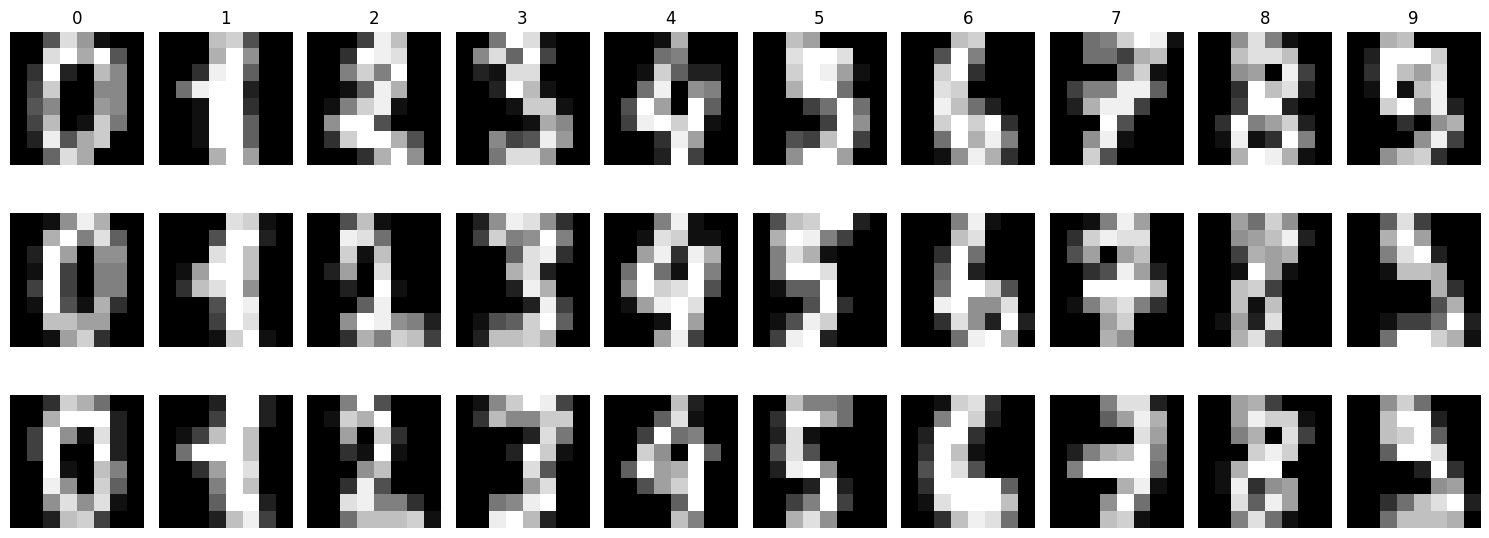

In [3]:
n_samples = 3
plt.figure(figsize=(15, 6))

for id_class, class_names in enumerate(classes):
    class_images = digits.images[id_class==digits.target][:n_samples]
    for idx, image in enumerate(class_images):
        plt_idx = idx * len(classes) + class_names + 1
        plt.subplot(n_samples, len(classes), plt_idx)
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        if idx == 0:
            plt.title(str(id_class))
plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
from sklearn.model_selection import train_test_split

X_flat = X.reshape(X.shape[0], -1).astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.25, random_state=42, stratify=y
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1347, 64)
Training labels shape:  (1347,)
Test data shape:  (450, 64)
Test labels shape:  (450,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
y_pred = classifier.predict(X_test, k=3)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


Размер матрицы расстояний: (450, 1347)


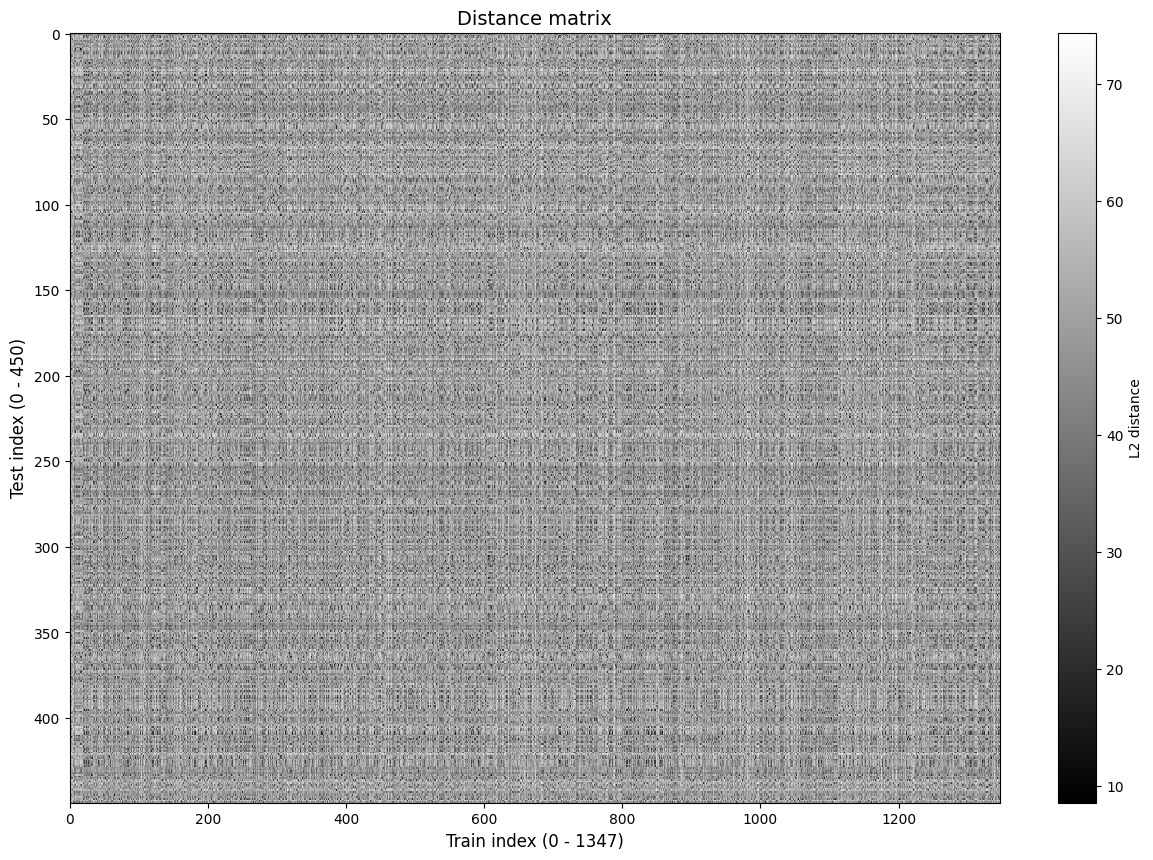

In [7]:
dists = classifier.compute_distances_two_loops(X_test)
print(f"Размер матрицы расстояний: {dists.shape}")

plt.figure(figsize=(15, 10))
plt.imshow(dists, interpolation='nearest', aspect='auto')
plt.colorbar(label='L2 distance')
plt.xlabel('Train index (0 - 1347)', fontsize=12)
plt.ylabel('Test index (0 - 450)', fontsize=12)
plt.title('Distance matrix', fontsize=14)
plt.show()

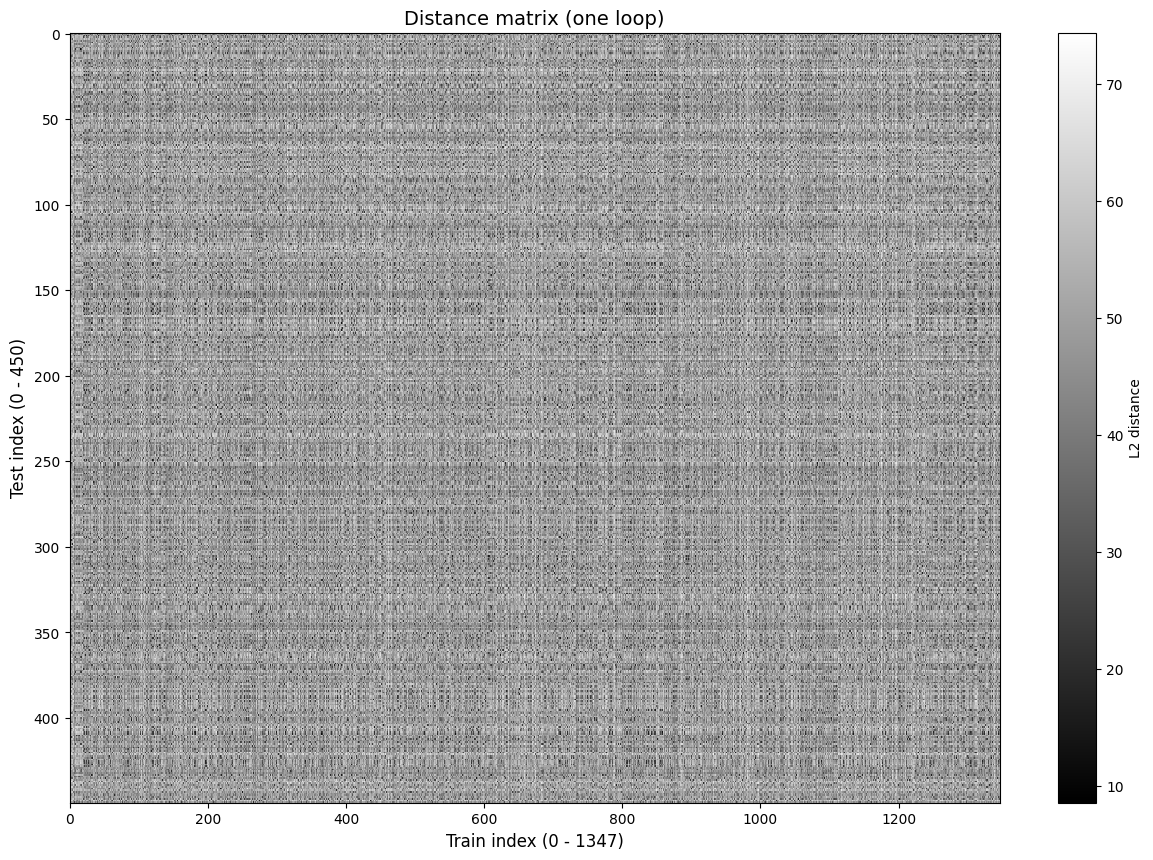

In [8]:
dists_one_loop = classifier.compute_distances_one_loop(X_test)

plt.figure(figsize=(15, 10))
plt.imshow(dists_one_loop, interpolation='nearest', aspect='auto')
plt.colorbar(label='L2 distance')
plt.xlabel('Train index (0 - 1347)', fontsize=12)
plt.ylabel('Test index (0 - 450)', fontsize=12)
plt.title('Distance matrix (one loop)', fontsize=14)
plt.show()

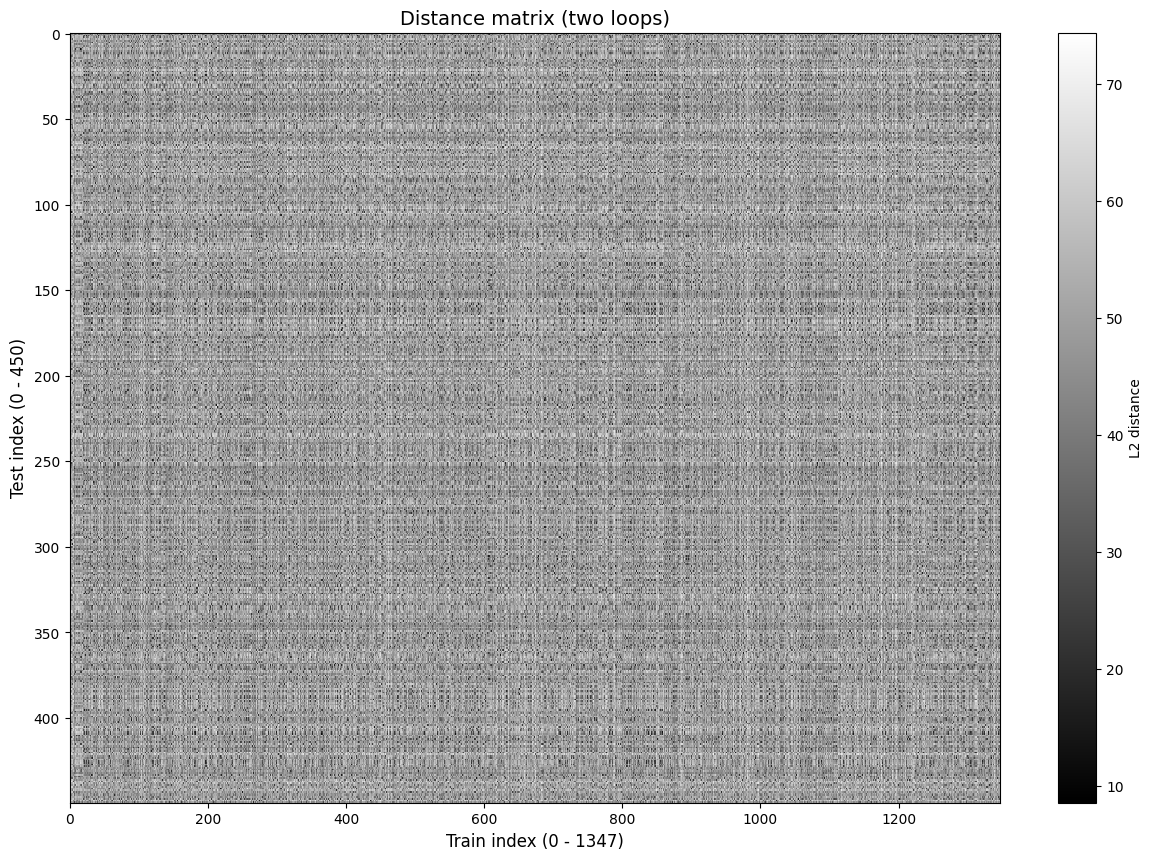

In [9]:
dists_two_loop = classifier.compute_distances_two_loops(X_test)

plt.figure(figsize=(15, 10))
plt.imshow(dists_two_loop, interpolation='nearest', aspect='auto')
plt.colorbar(label='L2 distance')
plt.xlabel('Train index (0 - 1347)', fontsize=12)
plt.ylabel('Test index (0 - 450)', fontsize=12)
plt.title('Distance matrix (two loops)', fontsize=14)
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [10]:
accuracy = np.mean(y_test == y_pred)
print(f'Доля правильно классифицированных изображений составляет {accuracy}')

Доля правильно классифицированных изображений составляет 0.9844444444444445


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

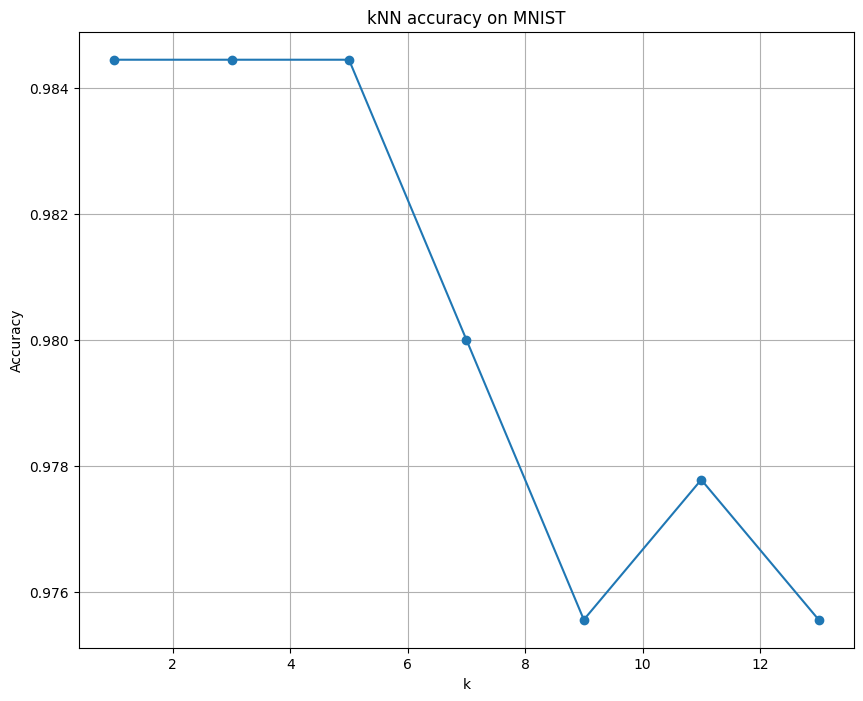

k=1: 0.9844
k=3: 0.9844
k=5: 0.9844
k=7: 0.9800
k=9: 0.9756
k=11: 0.9778
k=13: 0.9756


In [11]:
k_neighbors = [1, 3, 5, 7, 9, 11, 13]
k_accuracy = []

for k in k_neighbors:
    y_pred = classifier.predict(X_test, k=k, num_loops=0)
    k_accuracy.append(np.mean(y_pred==y_test))

plt.plot(k_neighbors, k_accuracy, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN accuracy on MNIST')
plt.grid(True)
plt.show()

for k, acc in zip(k_neighbors, k_accuracy):
    print(f'k={k}: {acc:.4f}')

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [12]:
num_folds = 5
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)
k_accuracies = {}

for k in k_neighbors:
    fold_accuracies = []
    for fold in range(num_folds):
        X_val_fold = X_train_folds[fold]
        y_val_fold = y_train_folds[fold]
        X_train_fold = np.vstack([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_fold = np.hstack([y_train_folds[i] for i in range(num_folds) if i != fold])

        fold_classifier = KNearestNeighbor()
        fold_classifier.train(X_train_fold, y_train_fold)
        y_val_pred = fold_classifier.predict(X_val_fold, k=k, num_loops=0)
        fold_accuracies.append(np.mean(y_val_pred == y_val_fold))

    k_accuracies[k] = fold_accuracies

for k in sorted(k_accuracies):
    print(k, k_accuracies[k], np.mean(k_accuracies[k]))

best_k = max(k_neighbors, key=lambda k: (np.mean(k_accuracies[k]), -k))
print('Best k:', best_k)

1 [np.float64(0.9962962962962963), np.float64(0.9814814814814815), np.float64(0.9925650557620818), np.float64(0.9888475836431226), np.float64(0.9925650557620818)] 0.9903510945890128
3 [np.float64(0.9888888888888889), np.float64(0.9777777777777777), np.float64(0.9925650557620818), np.float64(0.9888475836431226), np.float64(0.9851301115241635)] 0.986641883519207
5 [np.float64(0.9888888888888889), np.float64(0.9777777777777777), np.float64(0.9814126394052045), np.float64(0.9888475836431226), np.float64(0.9888475836431226)] 0.9851548946716233
7 [np.float64(0.9851851851851852), np.float64(0.9666666666666667), np.float64(0.9851301115241635), np.float64(0.9851301115241635), np.float64(0.9925650557620818)] 0.9829354261324521
9 [np.float64(0.9851851851851852), np.float64(0.9703703703703703), np.float64(0.9814126394052045), np.float64(0.9814126394052045), np.float64(0.9888475836431226)] 0.9814456836018174
11 [np.float64(0.9777777777777777), np.float64(0.9666666666666667), np.float64(0.9739776951


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [13]:
classifier.train(X_train, y_train)
y_pred = classifier.predict(X_test, k=best_k, num_loops=0)
accuracy = np.mean(y_test == y_pred)
print(f'Доля правильно классифицированных изображений составляет {accuracy}')

Доля правильно классифицированных изображений составляет 0.9844444444444445


1.11 Сделайте выводы по результатам 1 части задания.

В первой части задания был разработан и протестирован алгоритм k ближайших соседей (kNN) на датасете `MNIST`. После разделения данных на обучающую и тестовую выборки классификатор продемонстрировал высокую эффективность: наилучшие результаты на тестовой выборке обеспечиваются при k = [1, 3, 5] и достигают точности в 0.9844, однако кросс-валидация выявила оптимальное значение k = 1 со средней точностью 0.9904. Полученные результаты отражают высокую эффективность метода ближайших соседей для данного набора данных, а применение кросс-валидации позволяет объективно выбрать наилучшую конфигурацию модели.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [14]:
from sklearn.model_selection import train_test_split

X_flat = X.reshape(X.shape[0], -1).astype(np.float64)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_flat, y, test_size=0.3, random_state=42, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_full, y_train_full, test_size=0.4, random_state=42, stratify=y_train_full
)


print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Validation data shape: ', X_dev.shape)
print('Validation labels shape: ', y_dev.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (754, 64)
Training labels shape:  (754,)
Validation data shape:  (503, 64)
Validation labels shape:  (503,)
Test data shape:  (540, 64)
Test labels shape:  (540,)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

[0.00000000e+00 3.16976127e-01 5.18169761e+00 1.18023873e+01
 1.18037135e+01 5.68169761e+00 1.33421751e+00 1.45888594e-01
 5.30503979e-03 1.98143236e+00]


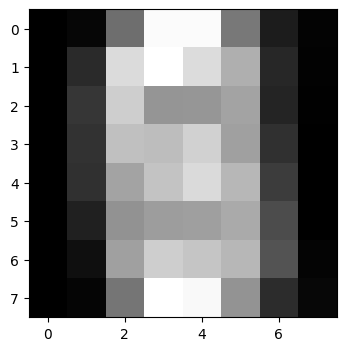

In [15]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) 
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape(8,8)) 
plt.show()

X_train -= mean_image
X_test -= mean_image
X_dev -= mean_image

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [16]:
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_test.shape, X_dev.shape)

(754, 65) (540, 65) (503, 65)


3.4 Реализуйте функции в classifiers/softmax.py




In [17]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(X_train.shape[1], 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.304157
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [18]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.040341 analytic: -0.040341, relative error: 3.005555e-09
numerical: 0.196840 analytic: 0.196840, relative error: 1.811007e-10
numerical: -0.016886 analytic: -0.016886, relative error: 1.055532e-09
numerical: 0.181236 analytic: 0.181236, relative error: 2.511104e-10
numerical: -0.243918 analytic: -0.243918, relative error: 3.943632e-10
numerical: 0.009057 analytic: 0.009057, relative error: 3.272396e-09
numerical: 0.030709 analytic: 0.030709, relative error: 6.624919e-10
numerical: -0.050795 analytic: -0.050795, relative error: 2.478989e-10
numerical: -0.179788 analytic: -0.179788, relative error: 2.856351e-10
numerical: 0.005873 analytic: 0.005873, relative error: 5.223701e-09
numerical: 0.197027 analytic: 0.197027, relative error: 1.767556e-10
numerical: -0.069470 analytic: -0.069470, relative error: 1.281496e-10
numerical: -0.064137 analytic: -0.064137, relative error: 1.052020e-10
numerical: 0.766898 analytic: 0.766898, relative error: 2.837454e-14
numerical: -0.002865

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [19]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.304157e+00 computed in 0.011943s
vectorized loss: 2.304157e+00 computed in 0.000000s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

In [20]:
from scripts.classifiers import Softmax

softmax = Softmax()

loss_hist = softmax.train(
    X_train, y_train,
    learning_rate=5e-1,
    reg=5e-4,
    num_iters=1000,
    batch_size=200,
    verbose=True
)

y_test_pred = softmax.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

iteration 0 / 1000: loss 2.302448
iteration 100 / 1000: loss 0.012280
iteration 200 / 1000: loss 0.010853
iteration 300 / 1000: loss 0.009716
iteration 400 / 1000: loss 0.009527
iteration 500 / 1000: loss 0.009230
iteration 600 / 1000: loss 0.009015
iteration 700 / 1000: loss 0.008194
iteration 800 / 1000: loss 0.008294
iteration 900 / 1000: loss 0.008591
Test accuracy: 95.19%


Визуализация Loss при обучении

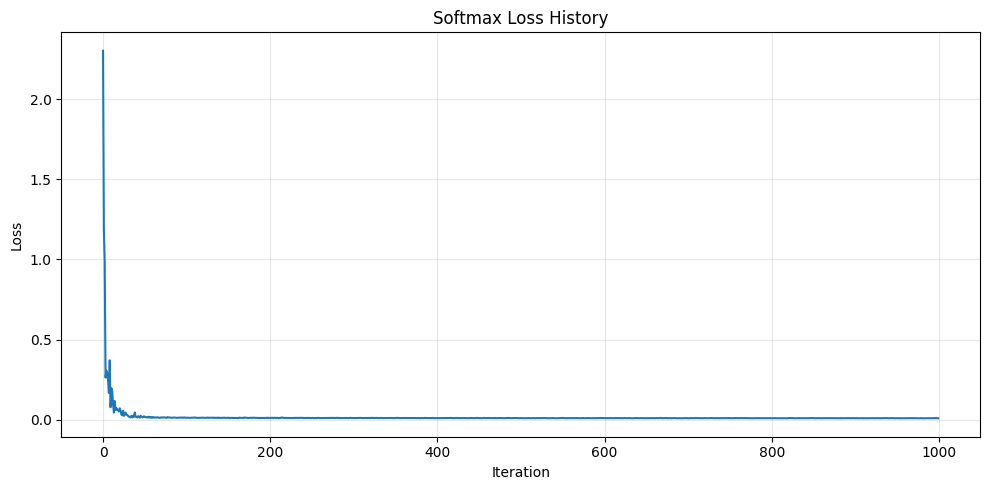

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(loss_hist)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Softmax Loss History')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [22]:
from scripts.classifiers import Softmax

results = {}
best_val = -1
best_softmax = None
learning_rates = [1e-7, 5e-5, 1e-3, 5e-1]
regularization_strengths = [5e-5, 5e-4, 5e-3]

for learning_rate in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(
            X_train,
            y_train,
            learning_rate=learning_rate,
            reg=reg,
            num_iters=1500,
            batch_size=200,
            verbose=False,
        )
        train_accuracy = np.mean(softmax.predict(X_train) == y_train)
        val_accuracy = np.mean(softmax.predict(X_dev) == y_dev)
        results[(learning_rate, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

for (learning_rate, reg), (train_accuracy, val_accuracy) in sorted(results.items()):
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (learning_rate, reg, train_accuracy, val_accuracy))

print('best validation accuracy: %f' % best_val)
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)
print('test accuracy: %f' % test_accuracy)

lr 1.000000e-07 reg 5.000000e-05 train accuracy: 0.062334 val accuracy: 0.073559
lr 1.000000e-07 reg 5.000000e-04 train accuracy: 0.187003 val accuracy: 0.194831
lr 1.000000e-07 reg 5.000000e-03 train accuracy: 0.118037 val accuracy: 0.125249
lr 5.000000e-05 reg 5.000000e-05 train accuracy: 0.912467 val accuracy: 0.896620
lr 5.000000e-05 reg 5.000000e-04 train accuracy: 0.917772 val accuracy: 0.896620
lr 5.000000e-05 reg 5.000000e-03 train accuracy: 0.915119 val accuracy: 0.898608
lr 1.000000e-03 reg 5.000000e-05 train accuracy: 0.977454 val accuracy: 0.962227
lr 1.000000e-03 reg 5.000000e-04 train accuracy: 0.977454 val accuracy: 0.960239
lr 1.000000e-03 reg 5.000000e-03 train accuracy: 0.977454 val accuracy: 0.962227
lr 5.000000e-01 reg 5.000000e-05 train accuracy: 1.000000 val accuracy: 0.964215
lr 5.000000e-01 reg 5.000000e-04 train accuracy: 1.000000 val accuracy: 0.962227
lr 5.000000e-01 reg 5.000000e-03 train accuracy: 1.000000 val accuracy: 0.958250
best validation accuracy: 0.

3.10 Сделайте выводы по третьей части задания

В третьей части задания были реализован softmax-классификатор и стохастический градиентный спуск для его обучения. Значения найденных значений градиента показала очень малые значения относительной ошибки, что подтверждает корректность реализации функции потерь и её производных. Значения loss для наивной и векторизованной реализаций совпали, скорость векторизованной реализации выше, поэтому для оценки loss в классификаторе используется именно она.

При подборе гиперпараметров лучшая модель (leaning_rate = 5e-1, egularization strength = 5е-5) показала точность 0.9642 на валидационной выборке и 0.9500 на тестовой. Такие значения позволяют сделать вывод, что `softmax`-классификатор хорошо решает задачу распознавания цифр на наборе `MNIST`, хотя по качеству немного уступает `kNN` в рамках данного эксперимента. Однако в общем случае рассмотренный подход является более универсальным и масштабируемым, особенно в случае использования более сложных моделей машинного обучения.